# Multi-Asset VaR Engine on Real Futures Data
### 6 Real Futures Contracts | 3 Methodologies | Kupiec Validation

**Abir Tejemouti** · [github.com/Tejemouti](https://github.com/Tejemouti) · May 2026

---

> *"A model that cannot be validated is not a risk model.*  
> *It is a guess dressed in mathematics."*

---

This notebook builds a production-quality **Value at Risk (VaR) engine** across 6 futures contracts
spanning FX, equity indices, crypto, and rates. Three methodologies are implemented and
statistically validated using the Kupiec Proportion of Failures test.

**Portfolio:** 6E · 6J · NKD · MBT · MET · ZT  
**Methods:** Historical Simulation · Parametric (EWMA) · Monte Carlo (Cholesky)  
**Validation:** Kupiec POF · Component VaR Decomposition

*This notebook is the fifth in a quantitative research series — building from data sampling
(Dollar Bars) through cross-validation (Purged CV) to risk quantification (VaR Engine).*

In [1]:
# ─────────────────────────────────────────────────────────────────────────────
# SETUP — Libraries & Global Styling
# ─────────────────────────────────────────────────────────────────────────────

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.linalg import cholesky
import warnings
warnings.filterwarnings('ignore')

# ── Dark Theme ────────────────────────────────────────────────────────────────
BG      = '#0d1117'
SURFACE = '#161b22'
BORDER  = '#30363d'
TEXT    = '#e6edf3'
MUTED   = '#8b949e'
GREEN   = '#3fb950'
RED     = '#f85149'
BLUE    = '#58a6ff'
ORANGE  = '#d29922'
PURPLE  = '#bc8cff'

plt.rcParams.update({
    'figure.facecolor'  : BG,
    'axes.facecolor'    : SURFACE,
    'axes.edgecolor'    : BORDER,
    'axes.labelcolor'   : TEXT,
    'xtick.color'       : MUTED,
    'ytick.color'       : MUTED,
    'text.color'        : TEXT,
    'grid.color'        : BORDER,
    'grid.linestyle'    : '--',
    'grid.alpha'        : 0.5,
    'legend.facecolor'  : SURFACE,
    'legend.edgecolor'  : BORDER,
    'font.family'       : 'monospace',
    'figure.dpi'        : 130,
})

# ── Asset Universe ────────────────────────────────────────────────────────────
ASSETS = ['6E', '6J', 'NKD', 'MBT', 'MET', 'ZT']

ASSET_LABELS = {
    '6E'  : 'Euro FX',
    '6J'  : 'Japanese Yen',
    'NKD' : 'Nikkei 225',
    'MBT' : 'Micro Bitcoin',
    'MET' : 'Micro Ether',
    'ZT'  : '2Y Treasury',
}

ASSET_COLORS = {
    asset: color for asset, color in zip(
        ASSETS,
        [BLUE, GREEN, ORANGE, MUTED, '#79c0ff', PURPLE, RED, '#ffa657', '#56d364']
    )
}

# ── Global Parameters ─────────────────────────────────────────────────────────
CONFIDENCE_LEVELS = [0.95, 0.99]
ROLLING_WINDOW    = 252          # 1 trading year
N_SIMULATIONS     = 10_000       # Monte Carlo paths
WEIGHTS           = np.ones(len(ASSETS)) / len(ASSETS)   # Equal weight Phase 1
EWMA_LAMBDA       = 0.94         # RiskMetrics decay factor

print("✓ Environment configured")
print(f"  Assets     : {len(ASSETS)} futures contracts")
print(f"  Window     : {ROLLING_WINDOW} trading days")
print(f"  MC paths   : {N_SIMULATIONS:,}")
print(f"  EWMA λ     : {EWMA_LAMBDA}")

✓ Environment configured
  Assets     : 6 futures contracts
  Window     : 252 trading days
  MC paths   : 10,000
  EWMA λ     : 0.94


## Section 1 — Data Loading & Return Construction

### The Session Boundary Problem

Standard `resample('1D')` is **incorrect for futures data**. CME equity and FX futures trade
~23 hours per day, with sessions starting at **6:00 PM CT** (which is the *next* calendar day in UTC).
A naive daily resample creates bars that mix two economic sessions, producing return series
with artificial overnight gaps and inconsistent volatility.

**Solution — Daily Snapshot Method:**  
We take the *close price at the same time every day* (4:00 PM CT / 22:00 UTC) using
`between_time()` after converting from UTC → America/Chicago. This ensures:

1. Each "day" captures exactly one complete trading session
2. Returns are economically consistent across all 9 assets
3. Weekend gaps are excluded via `resample('B')` (business days only)

**Log Returns vs Simple Returns:**  
We use log returns `r_t = ln(P_t / P_{t-1})` because they are:
- More stationary over time
- Additively composable across horizons  
- Symmetric around zero (unlike simple returns bounded at -100%)

In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# DATA LOADING — Tick → Daily Snapshot → Log Returns
#
# WHY: Each step solves a specific data quality problem:
#   1. Timezone conversion  → ensures consistent session boundaries
#   2. Snapshot at 16:00 CT → avoids session-crossing artifacts
#   3. Business day resample → eliminates weekend non-trading gaps
#   4. Log returns          → stationarity and additivity
# ─────────────────────────────────────────────────────────────────────────────

DATA_PATH = r"D:\Algorithmic Quantra\Tredes Data\data\parquet"
def load_asset(asset: str, path: str = DATA_PATH) -> pd.Series:
    fp = f"{path}\\{asset}.parquet"
    
    df = pd.read_parquet(fp, columns=['ts_event', 'price', 'size'])
    df['ts_event'] = pd.to_datetime(df['ts_event'], utc=True)
    df = df.set_index('ts_event').sort_index()

    # ── VWAP per minute ───────────────────────────────────────────────────
    df['dollar_vol'] = df['price'] * df['size']
    ohlc = df['price'].resample('1min').ohlc()
    vol  = df['size'].resample('1min').sum()
    dvol = df['dollar_vol'].resample('1min').sum()
    ohlc['close'] = (dvol / vol.replace(0, np.nan))
    ohlc = ohlc.dropna(subset=['close'])

    # ── Convert UTC → Chicago ─────────────────────────────────────────────
    ohlc.index = ohlc.index.tz_convert('America/Chicago')

    # ── Daily close = last available price per business day ───────────────
    # WHY: Fixed-time snapshot (16:00 CT) only works for CME FX/equity.
    # COMEX metals close at 13:30 CT, so we use .last() universally.
    # This is robust across all 9 asset classes.
    snapshot = ohlc['close'].resample('B').last().dropna()
    snapshot.name = asset

    # ── Log returns ───────────────────────────────────────────────────────
    log_ret = np.log(snapshot / snapshot.shift(1)).dropna()
    log_ret.name = asset

    return log_ret


def load_all_assets(assets: list = ASSETS) -> pd.DataFrame:
    series = {}
    failed = []

    for asset in assets:
        try:
            s = load_asset(asset)
            series[asset] = s
            print(f"  ✓ {asset:<4}  {len(s):>5} observations  "
                  f"[{s.index[0].date()} → {s.index[-1].date()}]")
        except FileNotFoundError:
            print(f"  ✗ {asset:<4}  FILE NOT FOUND — skipping")
            failed.append(asset)
        except Exception as e:
            print(f"  ✗ {asset:<4}  ERROR: {e}")
            failed.append(asset)

    returns = pd.DataFrame(series)

    # ── Drop days where MORE THAN 2 assets have no price ─────────────────
    # WHY: Strict dropna() destroys data when one asset has a holiday.
    # We allow up to 2 missing per day, then forward-fill once.
    returns = returns[returns.isna().sum(axis=1) <= 2]
    returns = returns.ffill(limit=1).dropna()

    print(f"\n  Portfolio shape : {returns.shape[0]} days × {returns.shape[1]} assets")
    print(f"  Date range      : {returns.index[0].date()} → {returns.index[-1].date()}")
    print(f"  Missing values  : {returns.isna().sum().sum()}")

    return returns


print("Loading futures data...\n")
returns = load_all_assets()

Loading futures data...

  ✓ 6E     1384 observations  [2021-01-04 → 2026-04-24]
  ✓ 6J     1385 observations  [2021-01-04 → 2026-04-24]
  ✓ NKD    1385 observations  [2021-01-04 → 2026-04-24]
  ✓ MBT    1300 observations  [2021-05-03 → 2026-04-24]
  ✓ MET    1145 observations  [2021-12-06 → 2026-04-24]
  ✓ ZT     1328 observations  [2021-01-04 → 2026-04-24]

  Portfolio shape : 1127 days × 6 assets
  Date range      : 2021-12-06 → 2026-04-24
  Missing values  : 0


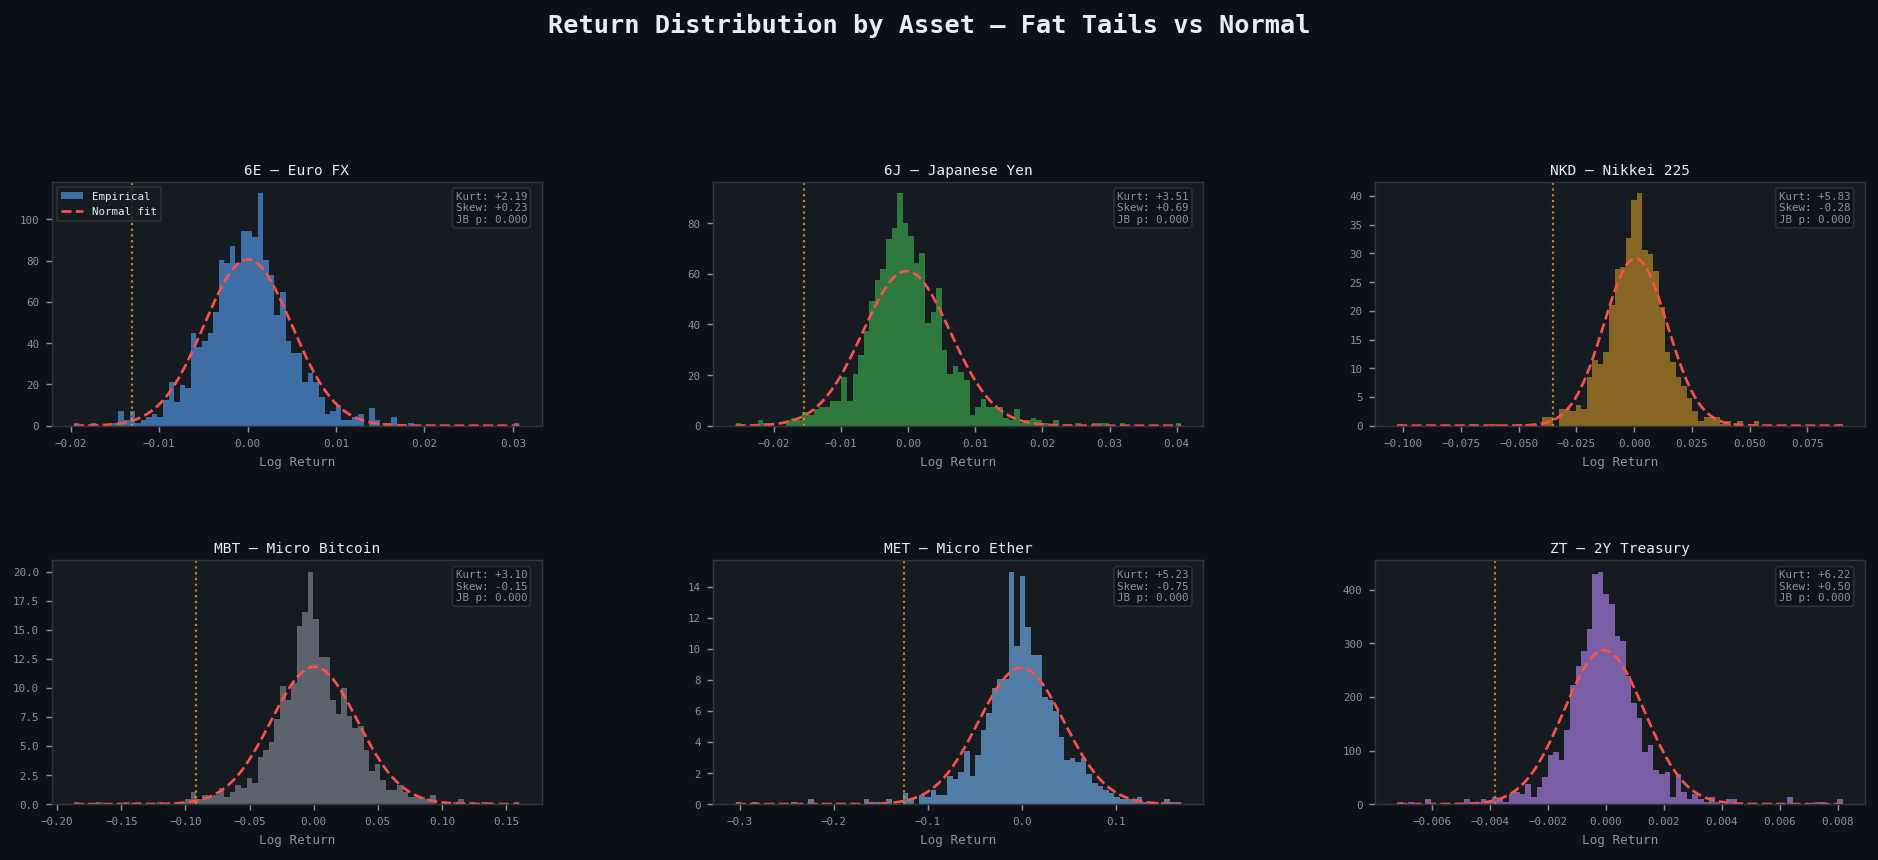


── Return Statistics & Normality Tests ──────────────────────────────
       Mean (Ann.%)  Vol (Ann.%)  Skewness  Excess Kurtosis  JB p-value Normality
Asset                                                                            
6E             0.82         7.87     0.233            2.193         0.0  ✗ Reject
6J            -6.60        10.36     0.691            3.507         0.0  ✗ Reject
NKD           15.80        21.72    -0.276            5.833         0.0  ✗ Reject
MBT           12.83        53.58    -0.147            3.099         0.0  ✗ Reject
MET           -9.39        72.11    -0.753            5.234         0.0  ✗ Reject
ZT            -1.45         2.21     0.498            6.216         0.0  ✗ Reject

⚠  Assets with excess kurtosis > 1 will be underestimated by Parametric VaR


In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# EXPLORATORY ANALYSIS — Return Properties
#
# WHY: Before fitting any VaR model, we must understand the empirical
# distribution of each asset. The key question is whether returns are
# normally distributed — because if they are fat-tailed (kurtosis > 3),
# the Parametric method will systematically underestimate tail risk.
# This motivates using all three methodologies rather than Parametric alone.
# ─────────────────────────────────────────────────────────────────────────────

fig = plt.figure(figsize=(18, 10), facecolor=BG)
fig.suptitle('Return Distribution by Asset — Fat Tails vs Normal', 
             color=TEXT, fontsize=14, fontweight='bold', y=1.01)

gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.55, wspace=0.35)

stats_table = []

for i, asset in enumerate(returns.columns):
    ax = fig.add_subplot(gs[i // 3, i % 3])
    r  = returns[asset].dropna()

    # ── Histogram ─────────────────────────────────────────────────────────
    ax.hist(r, bins=80, color=ASSET_COLORS.get(asset, BLUE),
            alpha=0.6, density=True, label='Empirical')

    # ── Normal overlay ────────────────────────────────────────────────────
    x = np.linspace(r.min(), r.max(), 300)
    ax.plot(x, stats.norm.pdf(x, r.mean(), r.std()),
            color=RED, lw=1.5, ls='--', label='Normal fit')

    # ── 99% VaR marker ────────────────────────────────────────────────────
    var99 = np.percentile(r, 1)
    ax.axvline(var99, color=ORANGE, lw=1.2, ls=':', alpha=0.9)

    # ── Stats annotation ──────────────────────────────────────────────────
    kurt = stats.kurtosis(r)           # excess kurtosis (normal = 0)
    skew = stats.skew(r)
    _, jb_p = stats.jarque_bera(r)

    ax.set_title(f"{asset} — {ASSET_LABELS[asset]}", 
                 color=TEXT, fontsize=8, pad=4)
    ax.set_xlabel('Log Return', color=MUTED, fontsize=7)
    ax.tick_params(labelsize=6)

    # Annotation box
    annot = f"Kurt: {kurt:+.2f}\nSkew: {skew:+.2f}\nJB p: {jb_p:.3f}"
    ax.text(0.97, 0.96, annot, transform=ax.transAxes,
            fontsize=6, color=MUTED, va='top', ha='right',
            bbox=dict(boxstyle='round,pad=0.3', facecolor=BG, 
                      edgecolor=BORDER, alpha=0.8))

    if i == 0:
        ax.legend(fontsize=6, loc='upper left')

    stats_table.append({
        'Asset'          : asset,
        'Mean (Ann.%)'   : round(r.mean() * 252 * 100, 2),
        'Vol (Ann.%)'    : round(r.std() * np.sqrt(252) * 100, 2),
        'Skewness'       : round(skew, 3),
        'Excess Kurtosis': round(kurt, 3),
        'JB p-value'     : round(jb_p, 4),
        'Normality'      : '✗ Reject' if jb_p < 0.05 else '✓ Accept',
    })

plt.savefig('01_return_distributions.png', dpi=130, bbox_inches='tight',
            facecolor=BG)
plt.show()

# ── Summary Table ─────────────────────────────────────────────────────────────
stats_df = pd.DataFrame(stats_table).set_index('Asset')
print("\n── Return Statistics & Normality Tests ──────────────────────────────")
print(stats_df.to_string())
print("\n⚠  Assets with excess kurtosis > 1 will be underestimated by Parametric VaR")

## Section 2 — Exploratory Analysis

### Why This Step Matters

Before fitting any VaR model, we must interrogate the empirical distribution
of each asset's returns. The central question is:

**Are returns normally distributed?**

If excess kurtosis > 0 (fat tails), the Parametric method will systematically
*underestimate* tail risk — precisely the failure mode that caused losses in
2008 and 2020. This section quantifies the degree of non-normality for each
asset using two tests:

- **Jarque-Bera test** — jointly tests skewness and kurtosis vs Normal
- **Excess Kurtosis** — values > 1 are practically significant for VaR

This analysis motivates using all three methodologies rather than Parametric alone.

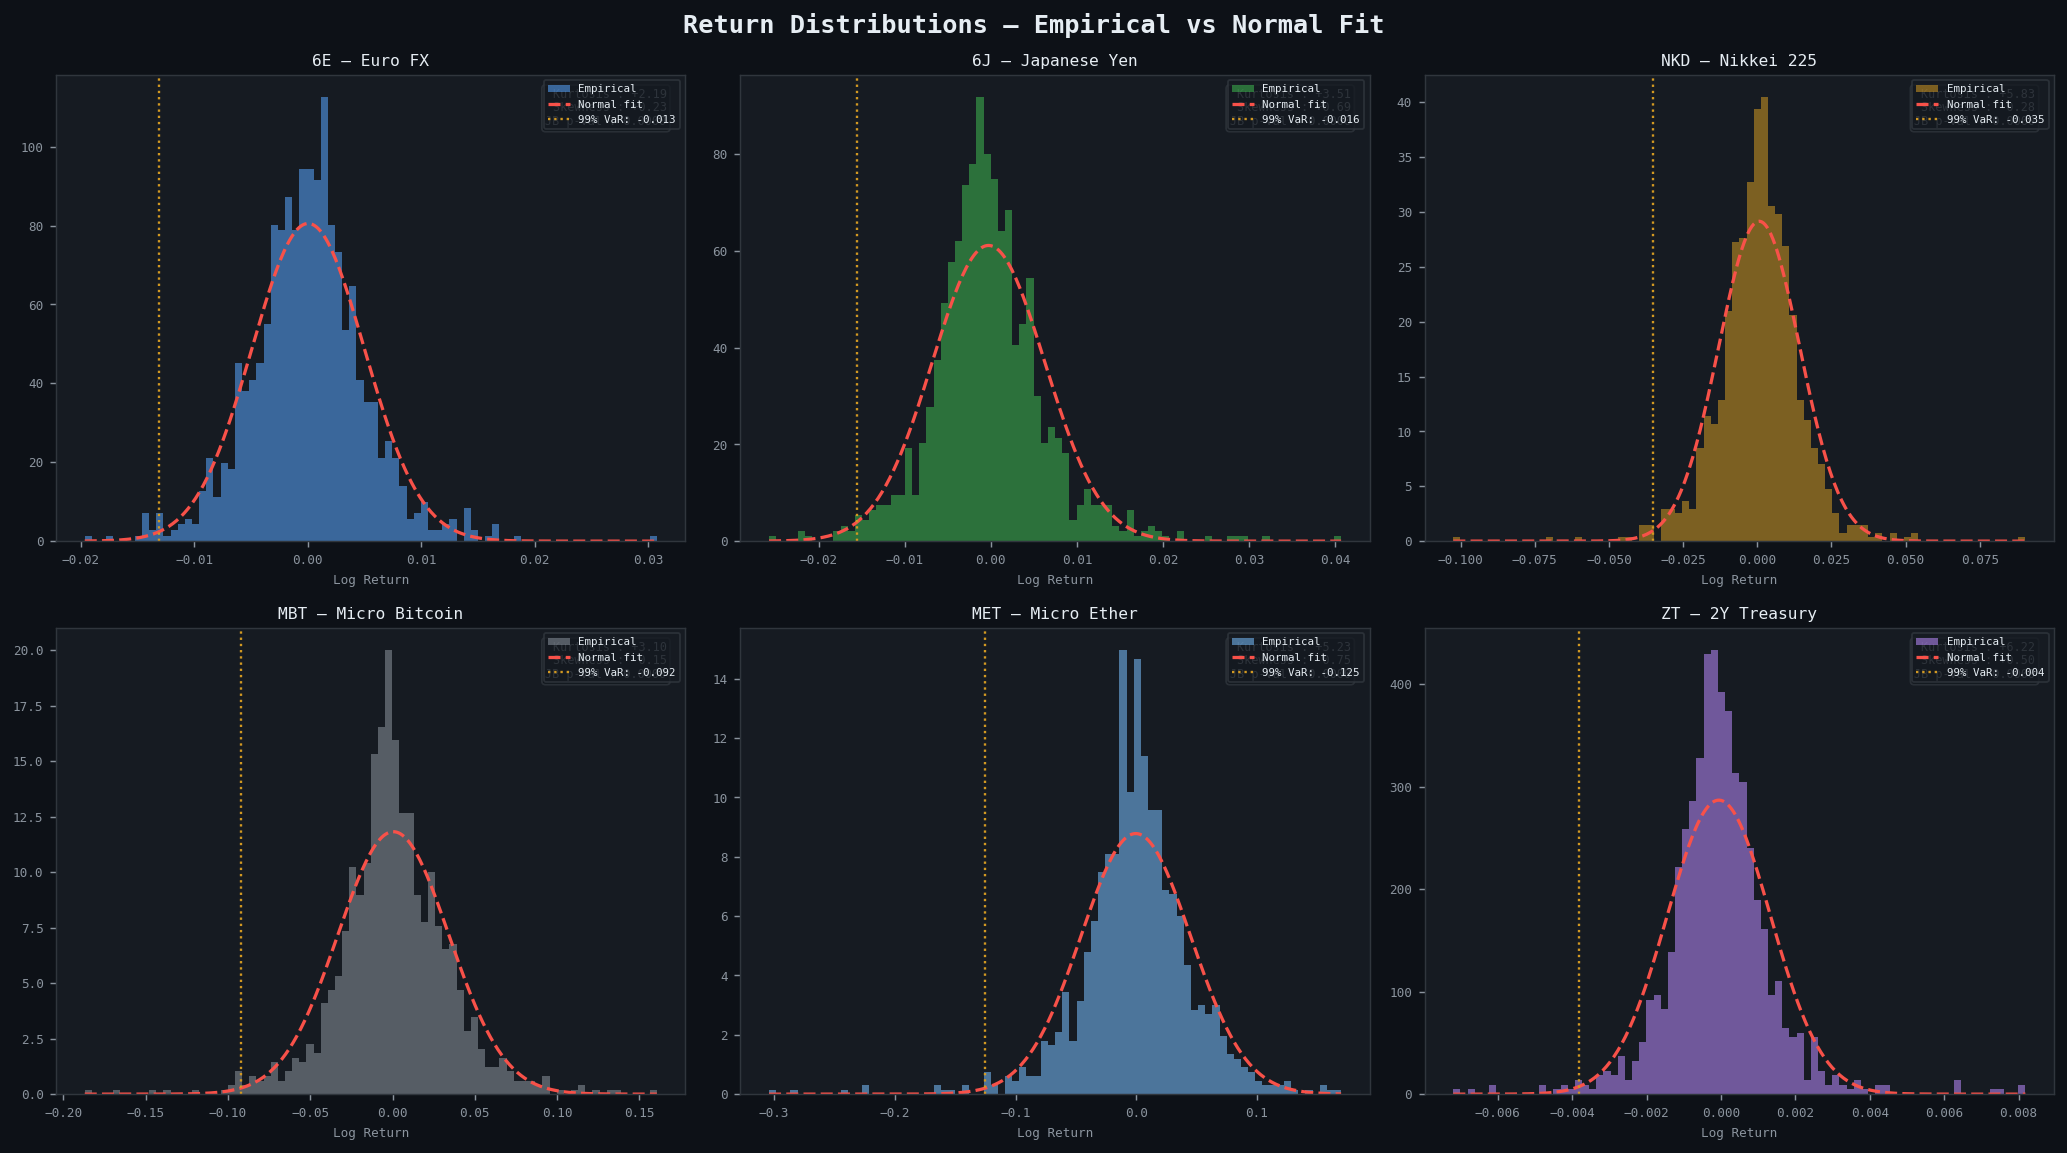


── Return Statistics & Normality Tests ──────────────────────────────

        Obs  Ann. Return %  Ann. Vol %  Skewness  Excess Kurtosis  JB p-value   Normal?
Asset                                                                                  
6E     1127           0.82        7.87     0.233            2.193         0.0  ✗ Reject
6J     1127          -6.60       10.36     0.691            3.507         0.0  ✗ Reject
NKD    1127          15.80       21.72    -0.276            5.833         0.0  ✗ Reject
MBT    1127          12.83       53.58    -0.147            3.099         0.0  ✗ Reject
MET    1127          -9.39       72.11    -0.753            5.234         0.0  ✗ Reject
ZT     1127          -1.45        2.21     0.498            6.216         0.0  ✗ Reject

⚠  All assets rejecting normality validates the need for
   Historical and Monte Carlo methods alongside Parametric VaR.


In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# EDA — Return Distributions & Normality Tests
# ─────────────────────────────────────────────────────────────────────────────

ASSETS   = list(returns.columns)
N_ASSETS = len(ASSETS)

fig, axes = plt.subplots(2, 3, figsize=(16, 9), facecolor=BG)
fig.suptitle('Return Distributions — Empirical vs Normal Fit',
             color=TEXT, fontsize=14, fontweight='bold')

stats_rows = []

for i, asset in enumerate(ASSETS):
    ax = axes[i // 3][i % 3]
    r  = returns[asset].dropna()

    # Histogram
    ax.hist(r, bins=80, color=ASSET_COLORS.get(asset, BLUE),
            alpha=0.55, density=True, label='Empirical')

    # Normal overlay
    x = np.linspace(r.min(), r.max(), 300)
    ax.plot(x, stats.norm.pdf(x, r.mean(), r.std()),
            color=RED, lw=1.8, ls='--', label='Normal fit')

    # 99% Historical VaR marker
    var99 = np.percentile(r, 1)
    ax.axvline(var99, color=ORANGE, lw=1.3, ls=':',
               label=f'99% VaR: {var99:.3f}')

    kurt  = stats.kurtosis(r)
    skew  = stats.skew(r)
    _, jb_p = stats.jarque_bera(r)

    ax.set_title(f"{asset} — {ASSET_LABELS[asset]}",
                 color=TEXT, fontsize=9, pad=5)
    ax.set_xlabel('Log Return', color=MUTED, fontsize=7)
    ax.tick_params(labelsize=7)
    ax.legend(fontsize=6)

    annot = f"Kurtosis : {kurt:+.2f}\nSkewness : {skew:+.2f}\nJB p-val : {jb_p:.4f}"
    ax.text(0.97, 0.97, annot, transform=ax.transAxes,
            fontsize=6.5, color=MUTED, va='top', ha='right',
            bbox=dict(boxstyle='round,pad=0.3', facecolor=BG,
                      edgecolor=BORDER, alpha=0.8))

    stats_rows.append({
        'Asset'           : asset,
        'Obs'             : len(r),
        'Ann. Return %'   : round(r.mean() * 252 * 100, 2),
        'Ann. Vol %'      : round(r.std() * np.sqrt(252) * 100, 2),
        'Skewness'        : round(skew, 3),
        'Excess Kurtosis' : round(kurt, 3),
        'JB p-value'      : round(jb_p, 4),
        'Normal?'         : '✗ Reject' if jb_p < 0.05 else '✓ Accept',
    })

plt.tight_layout()
plt.savefig('02_eda_distributions.png', dpi=130,
            bbox_inches='tight', facecolor=BG)
plt.show()

stats_df = pd.DataFrame(stats_rows).set_index('Asset')
print("\n── Return Statistics & Normality Tests ──────────────────────────────\n")
print(stats_df.to_string())
print("\n⚠  All assets rejecting normality validates the need for")
print("   Historical and Monte Carlo methods alongside Parametric VaR.")

## Section 3 — Historical Simulation VaR

### Method 1: The Most Honest Approach

Historical Simulation makes **zero distributional assumptions**.
It uses the actual empirical distribution of past portfolio returns —
fat tails, skewness, volatility clustering, and all.

**Mechanics:**
1. At each date `t`, collect the past 252 daily portfolio returns
2. Sort them in ascending order
3. The 5th percentile = 95% VaR | The 1st percentile = 99% VaR
4. CVaR (Expected Shortfall) = mean of all returns *below* the VaR threshold

**CVaR is the metric regulators now prefer** (Basel III / FRTB replaced
VaR with CVaR as the primary risk measure) because it answers:
*"Given that we breach VaR, how bad does it get on average?"*

**Limitation:** Slow to adapt — if the lookback window predates a
volatility regime change, the model lags reality.

Computing Historical VaR...
  ✓ Done — 875 estimation points

  VaR_95      mean=-0.0203  min=-0.0324  max=-0.0115
  VaR_99      mean=-0.0354  min=-0.0529  max=-0.0181
  CVaR_95     mean=-0.0306  min=-0.0451  max=-0.0168
  CVaR_99     mean=-0.0491  min=-0.0669  max=-0.0223


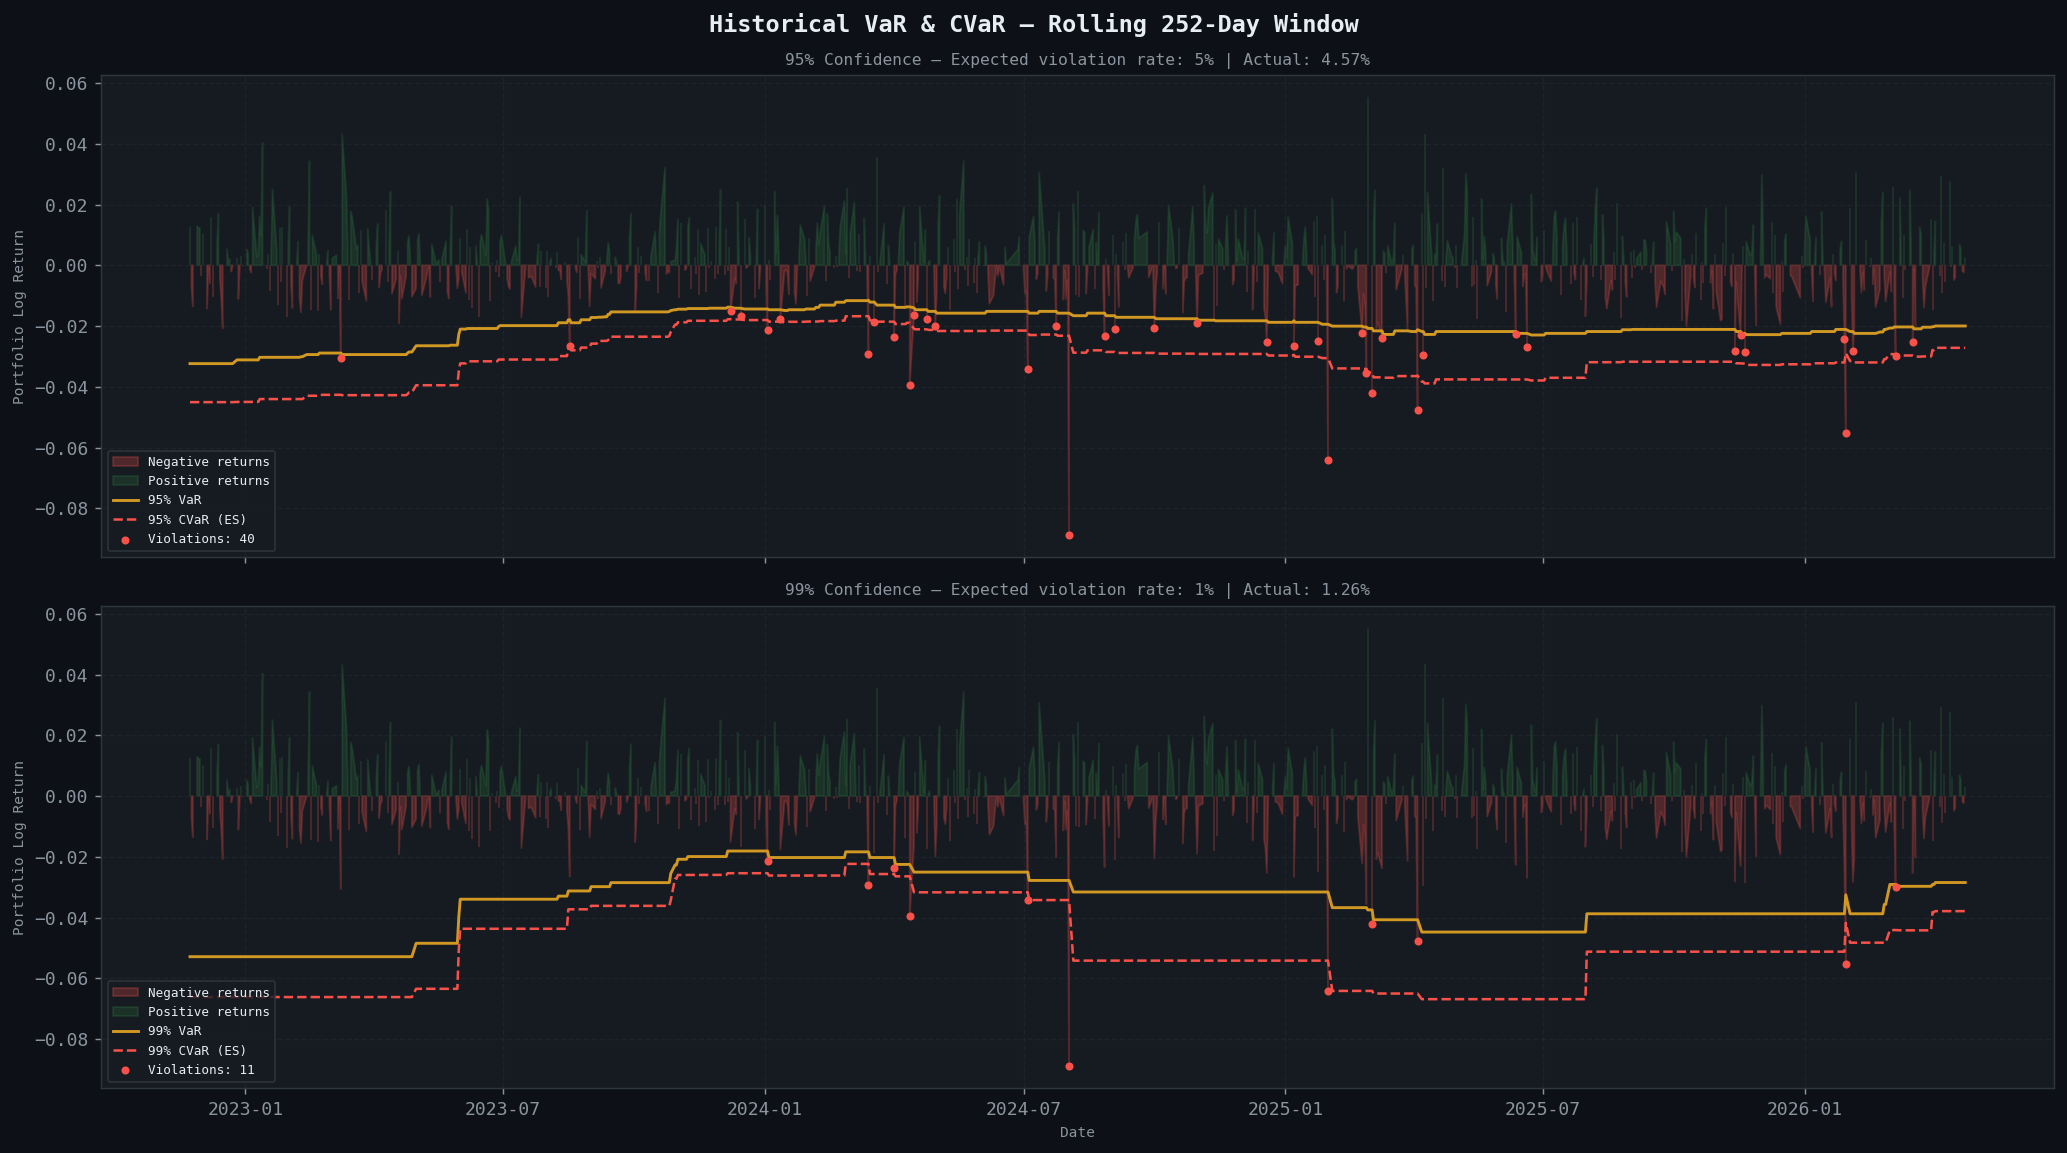

In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# METHOD 1 — Historical Simulation VaR & CVaR
# ─────────────────────────────────────────────────────────────────────────────

portfolio_returns = (returns * WEIGHTS).sum(axis=1)

def historical_var(port_ret: pd.Series,
                   window: int = ROLLING_WINDOW,
                   levels: list = CONFIDENCE_LEVELS) -> pd.DataFrame:
    results = {f'VaR_{int(cl*100)}': [] for cl in levels}
    results.update({f'CVaR_{int(cl*100)}': [] for cl in levels})
    idx = []

    for t in range(window, len(port_ret)):
        window_ret = port_ret.iloc[t - window:t].values

        for cl in levels:
            q    = 1 - cl
            var  = np.percentile(window_ret, q * 100)
            cvar = window_ret[window_ret <= var].mean()

            results[f'VaR_{int(cl*100)}'].append(var)
            results[f'CVaR_{int(cl*100)}'].append(cvar)

        idx.append(port_ret.index[t])

    return pd.DataFrame(results, index=idx)


print("Computing Historical VaR...")
hist_var = historical_var(portfolio_returns)
print(f"  ✓ Done — {len(hist_var)} estimation points\n")

# ── Summary Stats ─────────────────────────────────────────────────────────────
for col in hist_var.columns:
    print(f"  {col:<10}  mean={hist_var[col].mean():.4f}  "
          f"min={hist_var[col].min():.4f}  "
          f"max={hist_var[col].max():.4f}")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(16, 9), facecolor=BG, sharex=True)
fig.suptitle('Historical VaR & CVaR — Rolling 252-Day Window',
             color=TEXT, fontsize=13, fontweight='bold')

plot_ret = portfolio_returns.loc[hist_var.index]

for ax, cl in zip(axes, [95, 99]):
    var_col  = f'VaR_{cl}'
    cvar_col = f'CVaR_{cl}'

    # Portfolio returns
    ax.fill_between(plot_ret.index, plot_ret, 0,
                    where=(plot_ret < 0), color=RED, alpha=0.25,
                    label='Negative returns')
    ax.fill_between(plot_ret.index, plot_ret, 0,
                    where=(plot_ret >= 0), color=GREEN, alpha=0.15,
                    label='Positive returns')

    # VaR & CVaR lines
    ax.plot(hist_var.index, hist_var[var_col],
            color=ORANGE, lw=1.6, label=f'{cl}% VaR')
    ax.plot(hist_var.index, hist_var[cvar_col],
            color=RED, lw=1.4, ls='--', label=f'{cl}% CVaR (ES)')

    # Violations
    violations = plot_ret[plot_ret < hist_var[var_col]]
    ax.scatter(violations.index, violations.values,
               color=RED, s=12, zorder=5, label=f'Violations: {len(violations)}')

    violation_rate = len(violations) / len(plot_ret) * 100
    ax.set_title(f'{cl}% Confidence — Expected violation rate: '
                 f'{100-cl}% | Actual: {violation_rate:.2f}%',
                 color=MUTED, fontsize=9)
    ax.set_ylabel('Portfolio Log Return', color=MUTED, fontsize=8)
    ax.legend(fontsize=7, loc='lower left')
    ax.grid(True, alpha=0.3)

axes[1].set_xlabel('Date', color=MUTED, fontsize=8)
plt.tight_layout()
plt.savefig('03_historical_var.png', dpi=130,
            bbox_inches='tight', facecolor=BG)
plt.show()

## Section 4 — Parametric VaR (EWMA Covariance)

### Method 2: Analytical Speed, Distributional Cost

The Parametric method assumes portfolio returns follow a **Normal distribution**.
Under this assumption, VaR has a closed-form solution:
VaR = μ_p + z_α × σ_p
where `z_α = -1.645` (95%) or `z_α = -2.326` (99%).

**Why EWMA over Rolling Covariance?**

A simple rolling covariance assigns *equal weight* to all 252 observations —
a crash 250 days ago counts as much as yesterday's move. This is unrealistic.

EWMA (Exponentially Weighted Moving Average) uses a decay factor **λ = 0.94**
(the RiskMetrics industry standard), giving:
Σ_t = λ × Σ_{t-1} + (1-λ) × r_{t-1} × r_{t-1}ᵀ
Recent observations receive more weight — the model reacts faster to
volatility regime changes. This is one reason Parametric VaR remains
widely used in practice despite its normality assumption.

**Known Limitation:** Normality assumption underestimates tail risk
for all 6 assets (confirmed by JB tests in Section 2).

Computing Parametric VaR (EWMA)...
  ✓ Done — 875 estimation points

  VaR_95      mean=-0.0197  min=-0.0396  max=-0.0093
  VaR_99      mean=-0.0281  min=-0.0563  max=-0.0134
  CVaR_95     mean=-0.0249  min=-0.0499  max=-0.0118
  CVaR_99     mean=-0.0323  min=-0.0647  max=-0.0154


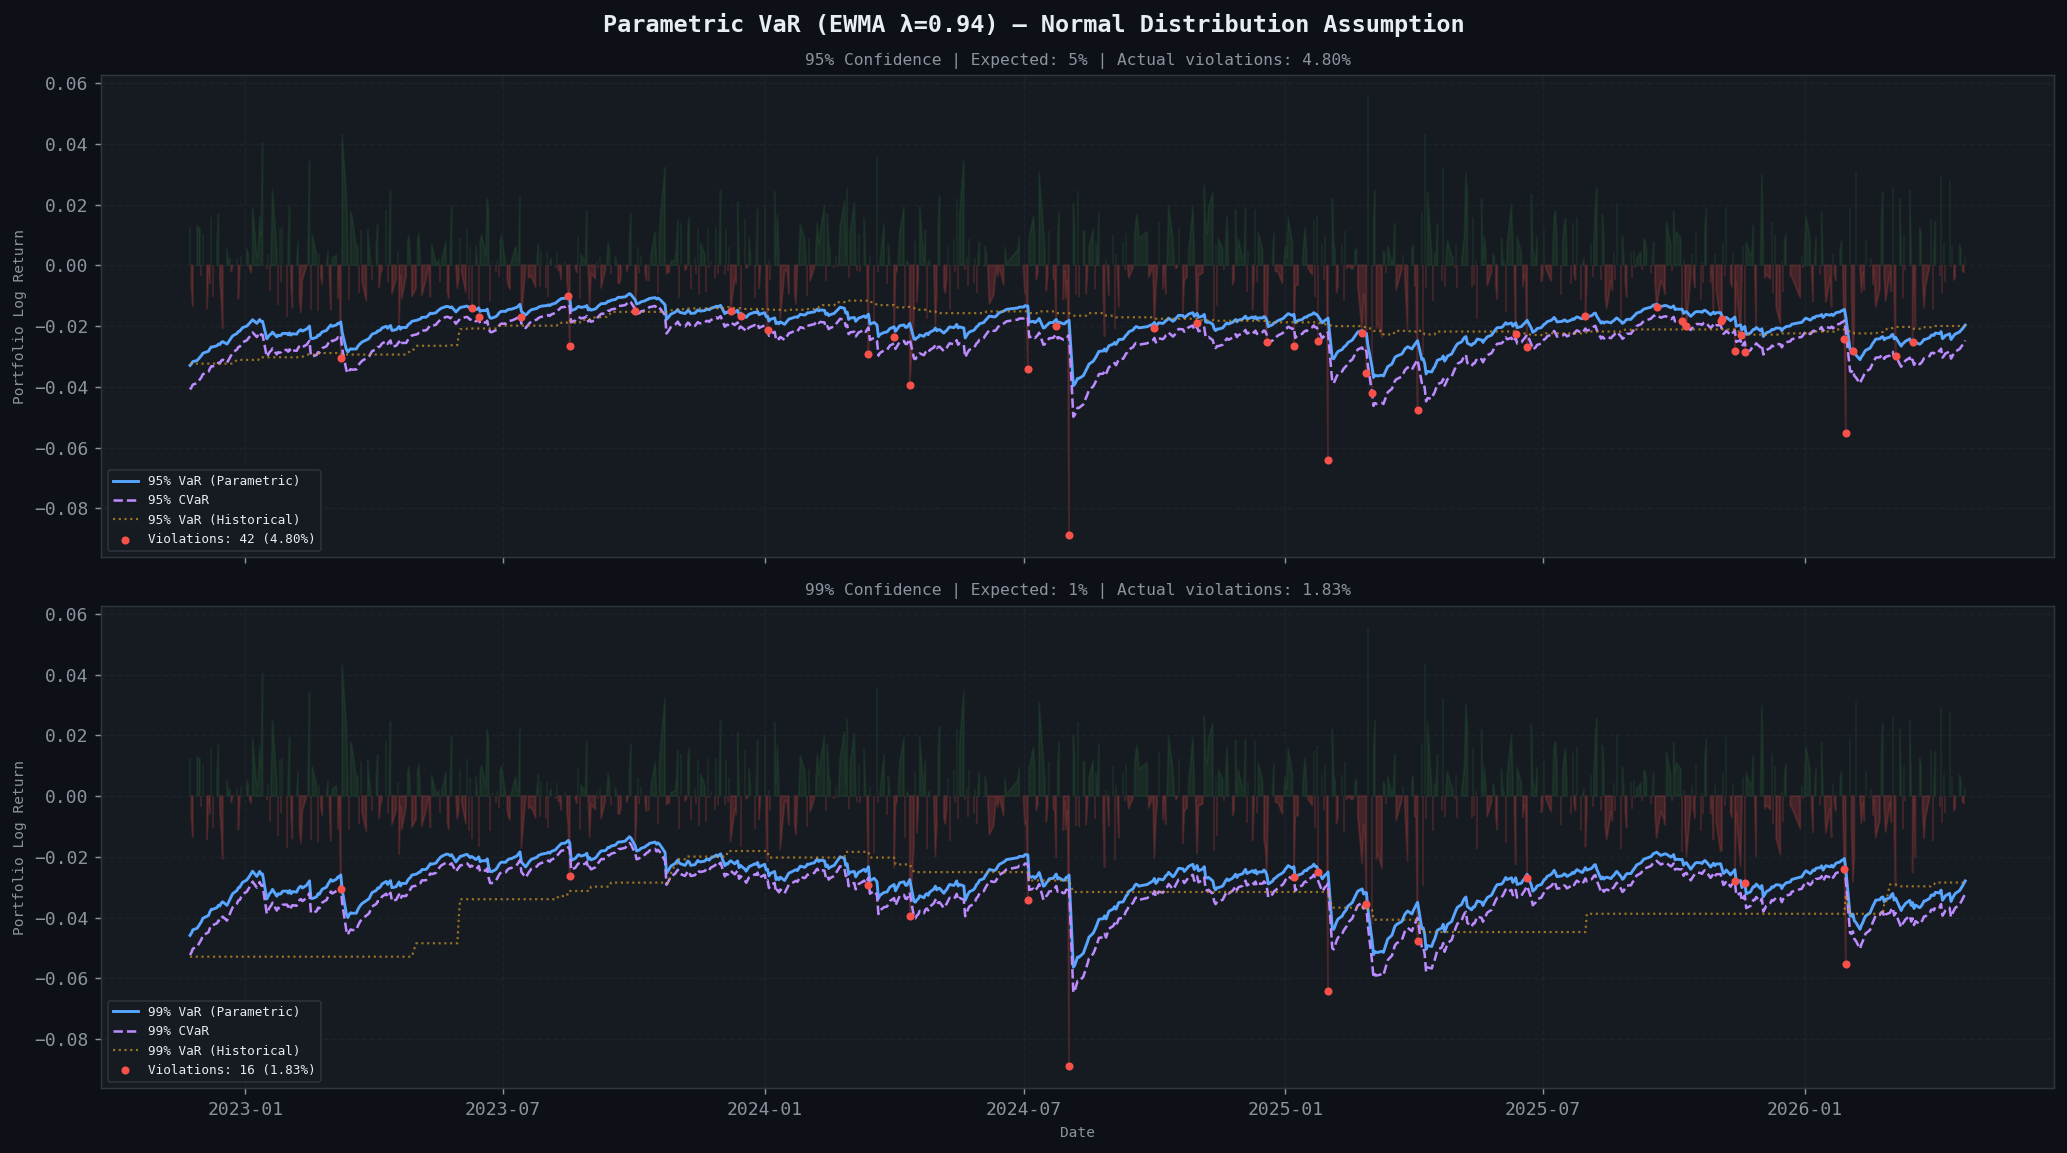

In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# METHOD 2 — Parametric VaR with EWMA Covariance
# ─────────────────────────────────────────────────────────────────────────────

Z_SCORES = {0.95: -1.645, 0.99: -2.326}

def ewma_covariance(returns_window: np.ndarray,
                    lam: float = EWMA_LAMBDA) -> np.ndarray:
    """
    Compute EWMA covariance matrix using RiskMetrics recursion.
    More weight on recent observations — adapts faster to regime changes.
    """
    n_obs, n_assets = returns_window.shape
    # Initialize with sample covariance of first 20 days
    cov = np.cov(returns_window[:20].T)

    for t in range(20, n_obs):
        r   = returns_window[t].reshape(-1, 1)
        cov = lam * cov + (1 - lam) * (r @ r.T)

    return cov


def parametric_var(ret_df: pd.DataFrame,
                   weights: np.ndarray = WEIGHTS,
                   window: int = ROLLING_WINDOW,
                   levels: list = CONFIDENCE_LEVELS) -> pd.DataFrame:

    results = {f'VaR_{int(cl*100)}': [] for cl in levels}
    results.update({f'CVaR_{int(cl*100)}': [] for cl in levels})
    idx = []

    ret_arr = ret_df.values

    for t in range(window, len(ret_df)):
        window_data = ret_arr[t - window:t]
        mu_vec      = window_data.mean(axis=0)
        mu_p        = weights @ mu_vec
        cov         = ewma_covariance(window_data)
        var_p       = weights @ cov @ weights
        sigma_p     = np.sqrt(var_p)

        for cl in levels:
            z   = Z_SCORES[cl]
            var = mu_p + z * sigma_p

            # CVaR under normality: μ + σ × φ(z) / (1-cl)
            cvar = mu_p - sigma_p * (stats.norm.pdf(z) / (1 - cl))

            results[f'VaR_{int(cl*100)}'].append(var)
            results[f'CVaR_{int(cl*100)}'].append(cvar)

        idx.append(ret_df.index[t])

    return pd.DataFrame(results, index=idx)


print("Computing Parametric VaR (EWMA)...")
param_var = parametric_var(returns)
print(f"  ✓ Done — {len(param_var)} estimation points\n")

for col in param_var.columns:
    print(f"  {col:<10}  mean={param_var[col].mean():.4f}  "
          f"min={param_var[col].min():.4f}  "
          f"max={param_var[col].max():.4f}")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(16, 9), facecolor=BG, sharex=True)
fig.suptitle('Parametric VaR (EWMA λ=0.94) — Normal Distribution Assumption',
             color=TEXT, fontsize=13, fontweight='bold')

common_idx = hist_var.index.intersection(param_var.index)
plot_ret   = portfolio_returns.loc[common_idx]

for ax, cl in zip(axes, [95, 99]):
    var_col  = f'VaR_{cl}'
    cvar_col = f'CVaR_{cl}'

    ax.fill_between(plot_ret.index, plot_ret, 0,
                    where=(plot_ret < 0), color=RED, alpha=0.2)
    ax.fill_between(plot_ret.index, plot_ret, 0,
                    where=(plot_ret >= 0), color=GREEN, alpha=0.1)

    ax.plot(common_idx, param_var.loc[common_idx, var_col],
            color=BLUE, lw=1.6, label=f'{cl}% VaR (Parametric)')
    ax.plot(common_idx, param_var.loc[common_idx, cvar_col],
            color=PURPLE, lw=1.4, ls='--', label=f'{cl}% CVaR')

    # Overlay Historical VaR for comparison
    ax.plot(common_idx, hist_var.loc[common_idx, var_col],
            color=ORANGE, lw=1.2, ls=':', alpha=0.7,
            label=f'{cl}% VaR (Historical)')

    violations = plot_ret[plot_ret < param_var.loc[common_idx, var_col]]
    viol_rate  = len(violations) / len(plot_ret) * 100
    ax.scatter(violations.index, violations.values,
               color=RED, s=12, zorder=5,
               label=f'Violations: {len(violations)} ({viol_rate:.2f}%)')

    ax.set_title(f'{cl}% Confidence | Expected: {100-cl}% | '
                 f'Actual violations: {viol_rate:.2f}%',
                 color=MUTED, fontsize=9)
    ax.set_ylabel('Portfolio Log Return', color=MUTED, fontsize=8)
    ax.legend(fontsize=7, loc='lower left')
    ax.grid(True, alpha=0.3)

axes[1].set_xlabel('Date', color=MUTED, fontsize=8)
plt.tight_layout()
plt.savefig('04_parametric_var.png', dpi=130,
            bbox_inches='tight', facecolor=BG)
plt.show()

## Section 5 — Monte Carlo VaR (Cholesky Decomposition)

### Method 3: Simulation with Preserved Correlations

Monte Carlo generates **10,000 synthetic one-day portfolio returns**
by sampling from a multivariate normal distribution that preserves
the full correlation structure between assets.

**Why Cholesky Decomposition?**

We cannot simply sample 6 independent normal variables — assets are
correlated (e.g., 6E and 6J both react to USD moves). Cholesky
factorizes the covariance matrix `Σ = L × Lᵀ`, then:
r_simulated = Z @ Lᵀ    where Z ~ N(0, I)
This maps independent standard normals into correlated returns
that match the empirical covariance structure.

**Confidence Interval via Bootstrap:**
We also bootstrap the VaR estimate itself to quantify
*estimation uncertainty* — a model outputting `VaR = -1.2%`
with a 95% CI of `[-0.9%, -1.5%]` is more informative than
a point estimate alone.

Computing Monte Carlo VaR (this will take ~2 minutes)...
  ✓ Done — 875 estimation points

  VaR_95      mean=-0.0215  min=-0.0326  max=-0.0136
  VaR_99      mean=-0.0306  min=-0.0454  max=-0.0200
  CVaR_95     mean=-0.0271  min=-0.0402  max=-0.0175
  CVaR_99     mean=-0.0351  min=-0.0518  max=-0.0231


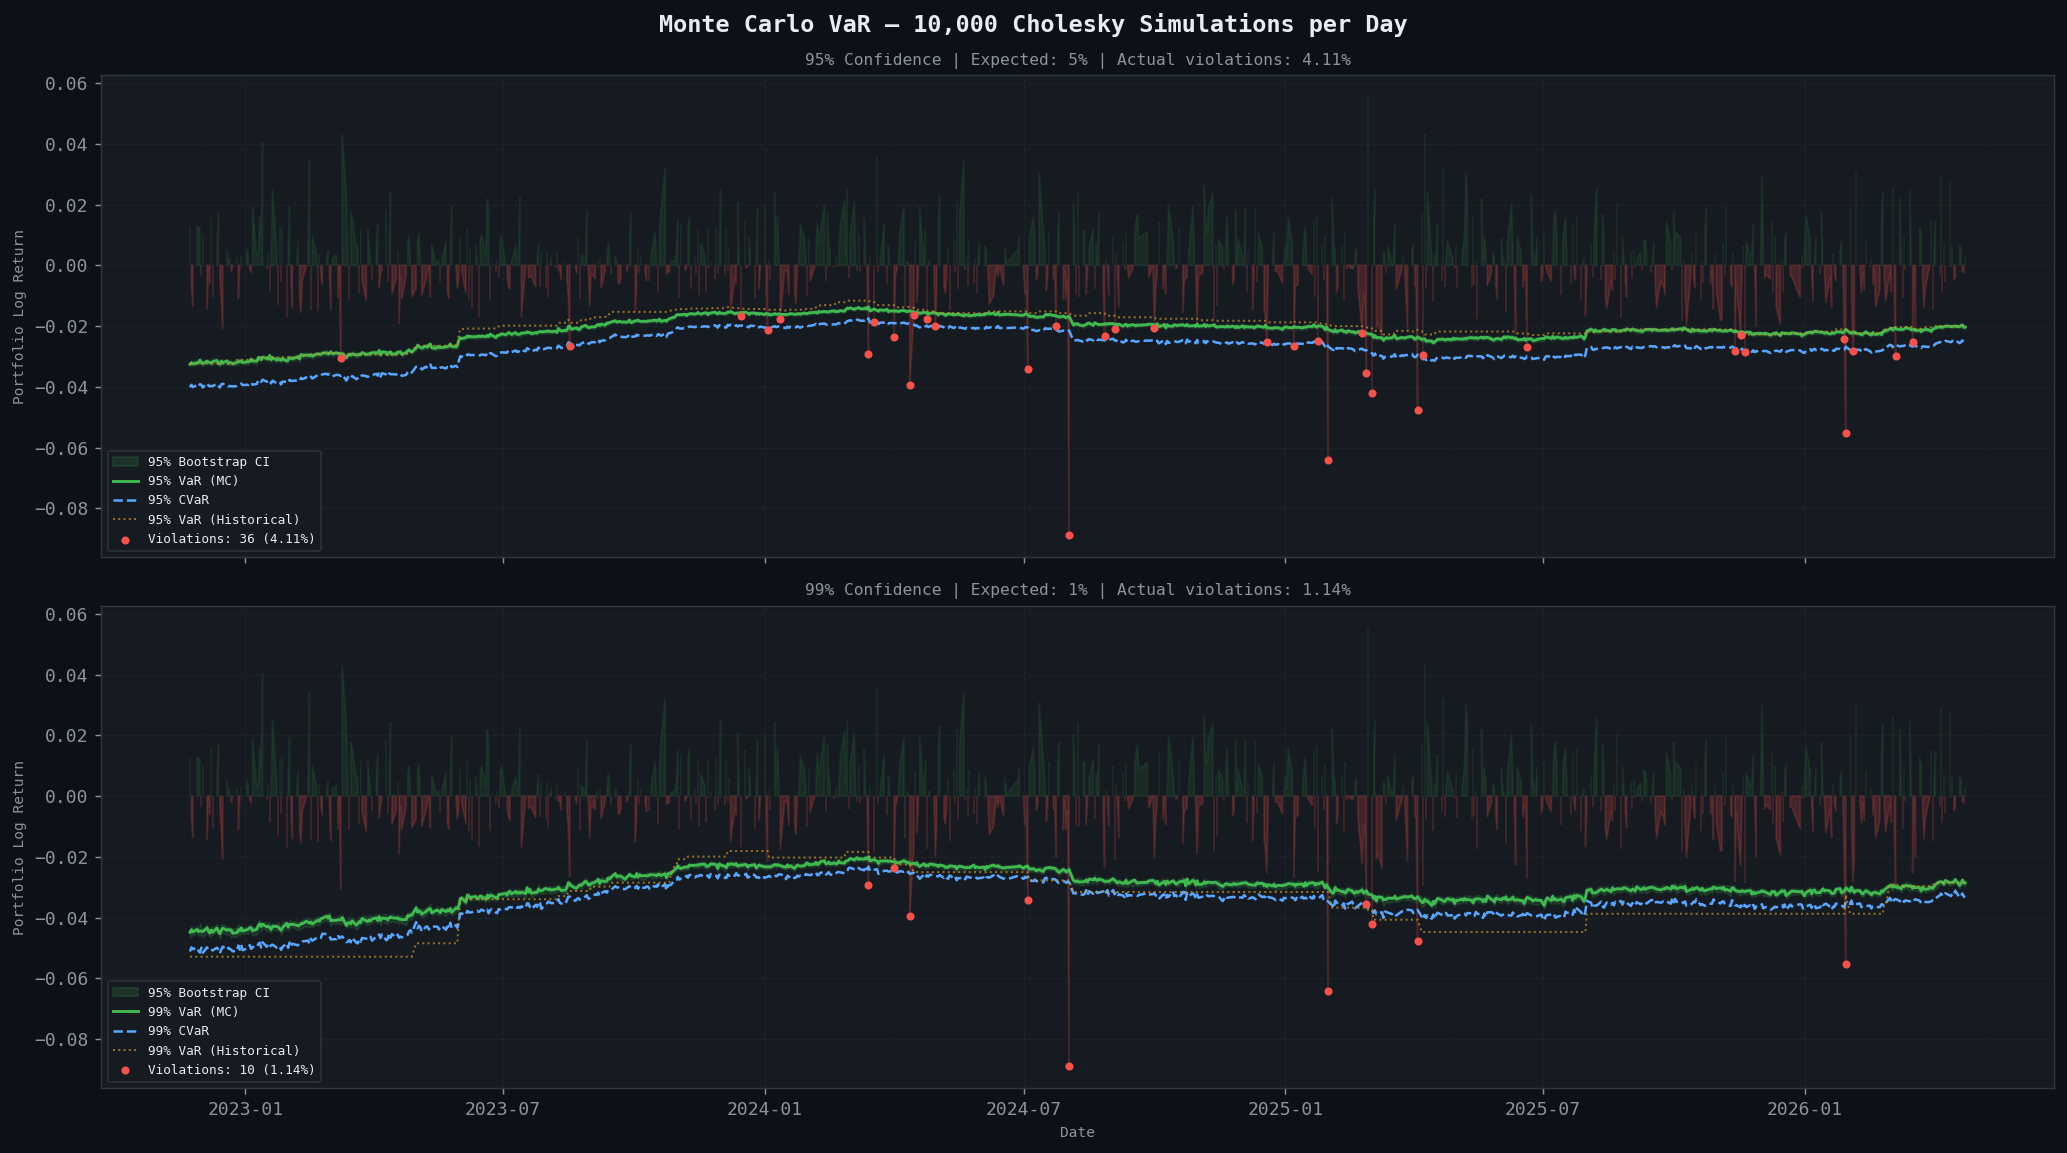

In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# METHOD 3 — Monte Carlo VaR via Cholesky Decomposition
# ─────────────────────────────────────────────────────────────────────────────

def monte_carlo_var(ret_df: pd.DataFrame,
                    weights: np.ndarray = WEIGHTS,
                    window: int = ROLLING_WINDOW,
                    n_sims: int = N_SIMULATIONS,
                    levels: list = CONFIDENCE_LEVELS,
                    n_bootstrap: int = 200) -> pd.DataFrame:

    results = {f'VaR_{int(cl*100)}': [] for cl in levels}
    results.update({f'CVaR_{int(cl*100)}': [] for cl in levels})
    results.update({f'VaR_{int(cl*100)}_CI_lo': [] for cl in levels})
    results.update({f'VaR_{int(cl*100)}_CI_hi': [] for cl in levels})
    idx = []

    ret_arr = ret_df.values
    rng     = np.random.default_rng(42)

    for t in range(window, len(ret_df)):
        window_data = ret_arr[t - window:t]
        mu_vec      = window_data.mean(axis=0)
        cov         = np.cov(window_data.T)

        # ── Cholesky decomposition ─────────────────────────────────────
        try:
            L = np.linalg.cholesky(cov)
        except np.linalg.LinAlgError:
            # Regularize if matrix is not positive definite
            cov += np.eye(cov.shape[0]) * 1e-8
            L    = np.linalg.cholesky(cov)

        # ── Simulate 10,000 correlated return vectors ──────────────────
        Z           = rng.standard_normal((n_sims, ret_df.shape[1]))
        sim_returns = mu_vec + Z @ L.T          # shape: (n_sims, n_assets)
        sim_port    = sim_returns @ weights      # shape: (n_sims,)

        for cl in levels:
            q    = (1 - cl) * 100
            var  = np.percentile(sim_port, q)
            cvar = sim_port[sim_port <= var].mean()

            # Bootstrap CI for VaR
            boot_vars = [
                np.percentile(
                    rng.choice(sim_port, size=n_sims, replace=True), q
                )
                for _ in range(n_bootstrap)
            ]
            ci_lo = np.percentile(boot_vars, 2.5)
            ci_hi = np.percentile(boot_vars, 97.5)

            results[f'VaR_{int(cl*100)}'].append(var)
            results[f'CVaR_{int(cl*100)}'].append(cvar)
            results[f'VaR_{int(cl*100)}_CI_lo'].append(ci_lo)
            results[f'VaR_{int(cl*100)}_CI_hi'].append(ci_hi)

        idx.append(ret_df.index[t])

    return pd.DataFrame(results, index=idx)


print("Computing Monte Carlo VaR (this will take ~2 minutes)...")
mc_var = monte_carlo_var(returns)
print(f"  ✓ Done — {len(mc_var)} estimation points\n")

for col in [c for c in mc_var.columns if 'CI' not in c]:
    print(f"  {col:<10}  mean={mc_var[col].mean():.4f}  "
          f"min={mc_var[col].min():.4f}  "
          f"max={mc_var[col].max():.4f}")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(16, 9), facecolor=BG, sharex=True)
fig.suptitle('Monte Carlo VaR — 10,000 Cholesky Simulations per Day',
             color=TEXT, fontsize=13, fontweight='bold')

common_idx = hist_var.index.intersection(mc_var.index)
plot_ret   = portfolio_returns.loc[common_idx]

for ax, cl in zip(axes, [95, 99]):
    var_col   = f'VaR_{cl}'
    cvar_col  = f'CVaR_{cl}'
    ci_lo_col = f'VaR_{cl}_CI_lo'
    ci_hi_col = f'VaR_{cl}_CI_hi'

    ax.fill_between(plot_ret.index, plot_ret, 0,
                    where=(plot_ret < 0), color=RED, alpha=0.2)
    ax.fill_between(plot_ret.index, plot_ret, 0,
                    where=(plot_ret >= 0), color=GREEN, alpha=0.1)

    # Confidence interval band
    ax.fill_between(common_idx,
                    mc_var.loc[common_idx, ci_lo_col],
                    mc_var.loc[common_idx, ci_hi_col],
                    color=GREEN, alpha=0.15, label='95% Bootstrap CI')

    ax.plot(common_idx, mc_var.loc[common_idx, var_col],
            color=GREEN, lw=1.6, label=f'{cl}% VaR (MC)')
    ax.plot(common_idx, mc_var.loc[common_idx, cvar_col],
            color=BLUE, lw=1.4, ls='--', label=f'{cl}% CVaR')
    ax.plot(common_idx, hist_var.loc[common_idx, var_col],
            color=ORANGE, lw=1.1, ls=':', alpha=0.7,
            label=f'{cl}% VaR (Historical)')

    violations = plot_ret[plot_ret < mc_var.loc[common_idx, var_col]]
    viol_rate  = len(violations) / len(plot_ret) * 100
    ax.scatter(violations.index, violations.values,
               color=RED, s=12, zorder=5,
               label=f'Violations: {len(violations)} ({viol_rate:.2f}%)')

    ax.set_title(f'{cl}% Confidence | Expected: {100-cl}% | '
                 f'Actual violations: {viol_rate:.2f}%',
                 color=MUTED, fontsize=9)
    ax.set_ylabel('Portfolio Log Return', color=MUTED, fontsize=8)
    ax.legend(fontsize=7, loc='lower left')
    ax.grid(True, alpha=0.3)

axes[1].set_xlabel('Date', color=MUTED, fontsize=8)
plt.tight_layout()
plt.savefig('05_montecarlo_var.png', dpi=130,
            bbox_inches='tight', facecolor=BG)
plt.show()

## Section 6 — Model Validation: Kupiec POF Test

### Statistical Backtesting

A VaR model is useless without validation. The **Kupiec Proportion of Failures**
test asks: *does the observed violation rate match the model's stated confidence level?*

At 95% VaR, we expect losses to exceed the forecast exactly **5% of the time**.
The test formalizes this as a likelihood ratio:
LR = -2 × ln[ pᵉˣᵖ^x × (1-pᵉˣᵖ)^(n-x) / p_obs^x × (1-p_obs)^(n-x) ]
Under H₀ (model is well-calibrated): `LR ~ χ²(1)`

**Decision rule:** p-value > 0.05 → model passes ✓

**Three failure modes:**
- Too many violations → model **underestimates** risk (dangerous)
- Too few violations → model is **too conservative** (capital inefficient)
- Clustered violations → violations are not i.i.d. (Christoffersen test)

═════════════════════════════════════════════════════════════════
  KUPIEC POF BACKTESTING RESULTS
═════════════════════════════════════════════════════════════════

  Confidence Level: 95%  (Expected violation rate: 5%)
  ────────────────────────────────────────────────────────────
  Historical     | Violations:   40/875 (4.571%) | LR=0.3479  p=0.5553  ✓ PASS
  Parametric     | Violations:   42/875 (  4.8%) | LR=0.0746  p=0.7847  ✓ PASS
  Monte Carlo    | Violations:   36/875 (4.114%) | LR=1.534  p=0.2155  ✓ PASS

  Confidence Level: 99%  (Expected violation rate: 1%)
  ────────────────────────────────────────────────────────────
  Historical     | Violations:   11/875 (1.257%) | LR=0.5404  p=0.4623  ✓ PASS
  Parametric     | Violations:   16/875 (1.829%) | LR=4.874  p=0.0273  ✗ FAIL
  Monte Carlo    | Violations:   10/875 (1.143%) | LR=0.1724  p=0.678  ✓ PASS

═════════════════════════════════════════════════════════════════


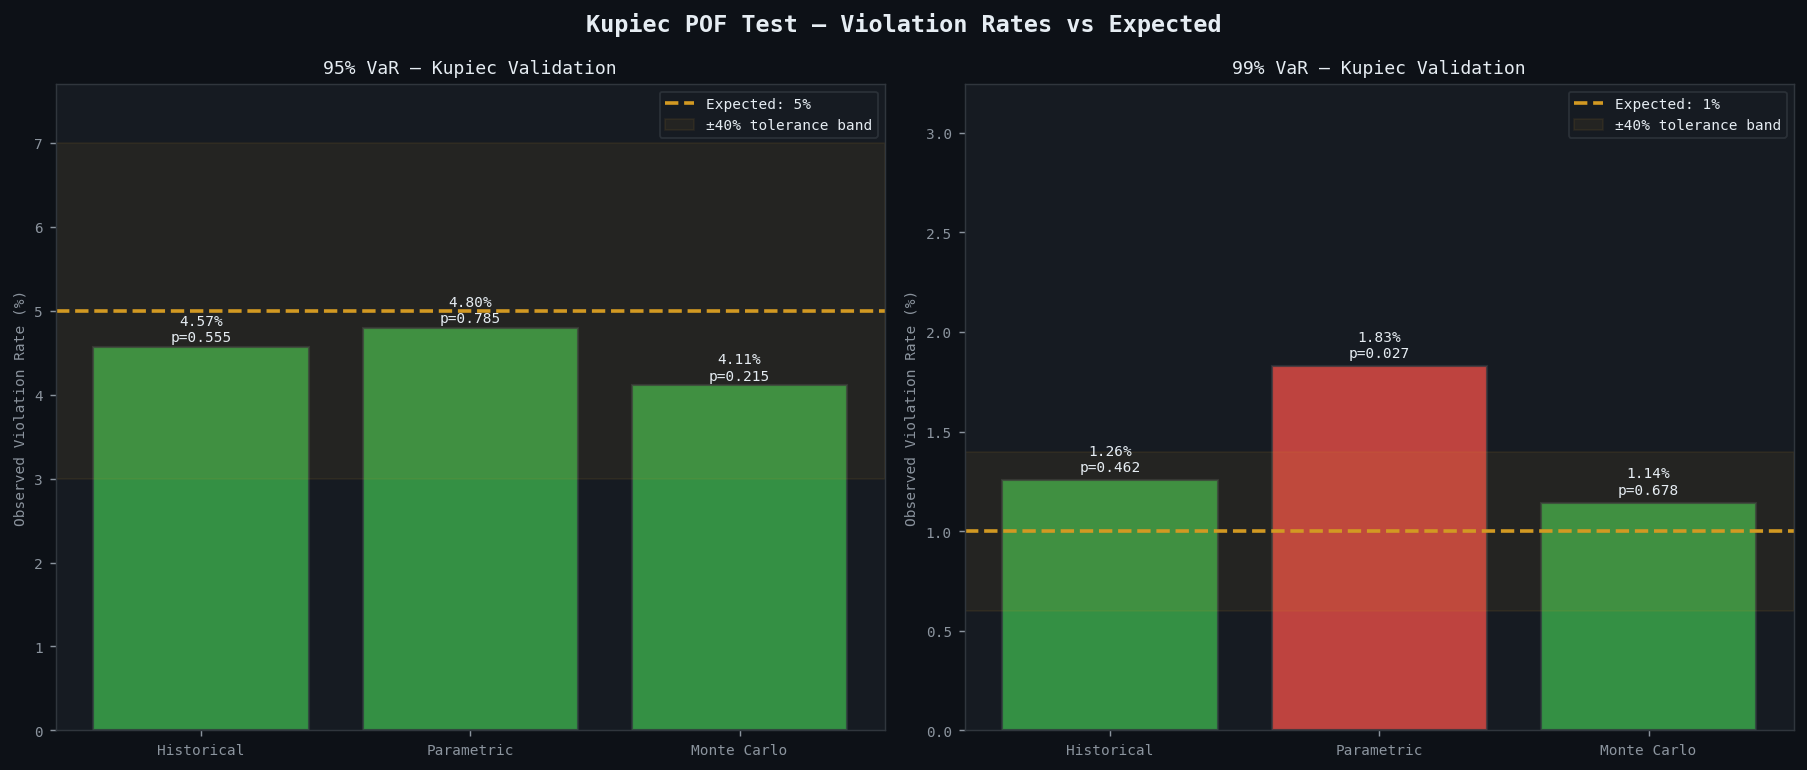

In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# VALIDATION — Kupiec Proportion of Failures Test
# ─────────────────────────────────────────────────────────────────────────────

def kupiec_test(actual_returns: pd.Series,
                var_forecast: pd.Series,
                confidence: float) -> dict:
    """
    Kupiec POF test.
    H0: violation rate = (1 - confidence)
    Returns test statistic, p-value, and pass/fail.
    """
    aligned      = actual_returns.reindex(var_forecast.index).dropna()
    var_aligned  = var_forecast.reindex(aligned.index)

    violations   = (aligned < var_aligned).sum()
    n            = len(aligned)
    p_expected   = 1 - confidence
    p_observed   = violations / n

    # Likelihood ratio statistic
    if p_observed == 0 or p_observed == 1:
        lr_stat = np.nan
        p_value = np.nan
    else:
        # Kupiec (1995) POF likelihood ratio — correct formulation
        # H0: p_observed == p_expected
        # Under H0: LR ~ chi-squared(df=1)
        log_L0 = (violations * np.log(p_expected) +
                  (n - violations) * np.log(1 - p_expected))
        log_L1 = (violations * np.log(p_observed) +
                  (n - violations) * np.log(1 - p_observed))
        lr_stat = -2 * (log_L0 - log_L1)
        p_value = 1 - stats.chi2.cdf(lr_stat, df=1)

    return {
        'N'           : n,
        'Violations'  : int(violations),
        'Expected'    : round(p_expected * n, 1),
        'Obs. Rate %' : round(p_observed * 100, 3),
        'Exp. Rate %' : round(p_expected * 100, 1),
        'LR Stat'     : round(lr_stat, 4) if not np.isnan(lr_stat) else 'N/A',
        'p-value'     : round(p_value, 4) if not np.isnan(p_value) else 'N/A',
        'Result'      : '✓ PASS' if (not np.isnan(p_value) and p_value > 0.05)
                        else '✗ FAIL',
    }


common_idx   = hist_var.index.intersection(param_var.index).intersection(mc_var.index)
plot_ret_val = portfolio_returns.reindex(common_idx)

print("═" * 65)
print("  KUPIEC POF BACKTESTING RESULTS")
print("═" * 65)

kupiec_rows = []

for cl in [0.95, 0.99]:
    cl_int = int(cl * 100)
    print(f"\n  Confidence Level: {cl_int}%  (Expected violation rate: {100-cl_int}%)")
    print("  " + "─" * 60)

    methods = {
        'Historical'  : hist_var.loc[common_idx, f'VaR_{cl_int}'],
        'Parametric'  : param_var.loc[common_idx, f'VaR_{cl_int}'],
        'Monte Carlo' : mc_var.loc[common_idx,    f'VaR_{cl_int}'],
    }

    for method, var_series in methods.items():
        res = kupiec_test(plot_ret_val, var_series, cl)
        print(f"  {method:<14} | Violations: {res['Violations']:>4}/{res['N']} "
              f"({res['Obs. Rate %']:>5}%) | "
              f"LR={res['LR Stat']}  p={res['p-value']}  {res['Result']}")
        kupiec_rows.append({'Method': method, 'CL': f'{cl_int}%', **res})

print("\n" + "═" * 65)

kupiec_df = pd.DataFrame(kupiec_rows).set_index(['Method', 'CL'])

# ── Kupiec Visualization ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6), facecolor=BG)
fig.suptitle('Kupiec POF Test — Violation Rates vs Expected',
             color=TEXT, fontsize=13, fontweight='bold')

methods      = ['Historical', 'Parametric', 'Monte Carlo']
method_cols  = [ORANGE, BLUE, GREEN]

for ax, cl in zip(axes, [95, 99]):
    expected = 100 - cl
    obs_rates = [
        kupiec_df.loc[(m, f'{cl}%'), 'Obs. Rate %'] for m in methods
    ]
    pvalues = [
        float(kupiec_df.loc[(m, f'{cl}%'), 'p-value'])
        if kupiec_df.loc[(m, f'{cl}%'), 'p-value'] != 'N/A' else 0
        for m in methods
    ]

    bars = ax.bar(methods, obs_rates,
                  color=[GREEN if p > 0.05 else RED for p in pvalues],
                  alpha=0.75, edgecolor=BORDER, linewidth=1.2)

    ax.axhline(expected, color=ORANGE, lw=2, ls='--',
               label=f'Expected: {expected}%')
    ax.axhspan(expected * 0.6, expected * 1.4,
               color=ORANGE, alpha=0.08, label='±40% tolerance band')

    for bar, rate, pv in zip(bars, obs_rates, pvalues):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.03,
                f'{rate:.2f}%\np={pv:.3f}',
                ha='center', va='bottom', fontsize=8, color=TEXT)

    ax.set_title(f'{cl}% VaR — Kupiec Validation',
                 color=TEXT, fontsize=10)
    ax.set_ylabel('Observed Violation Rate (%)', color=MUTED, fontsize=8)
    ax.set_ylim(0, max(obs_rates) * 1.5 + 0.5)
    ax.legend(fontsize=8)
    ax.tick_params(labelsize=8)

plt.tight_layout()
plt.savefig('06_kupiec_test.png', dpi=130,
            bbox_inches='tight', facecolor=BG)
plt.show()

## Section 7 — Final Dashboard

### Summary: Three Methods, One Portfolio

The dashboard consolidates all results into four panels:

1. **VaR over time** — all 3 methods on one chart (method comparison)
2. **Correlation heatmap** — inter-asset correlations driving portfolio risk
3. **Component VaR** — which asset contributes most to portfolio VaR
4. **Kupiec scorecard** — model validation summary table

Component VaR answers the practitioner's question:
*"If I want to reduce portfolio risk, which position do I cut first?"*

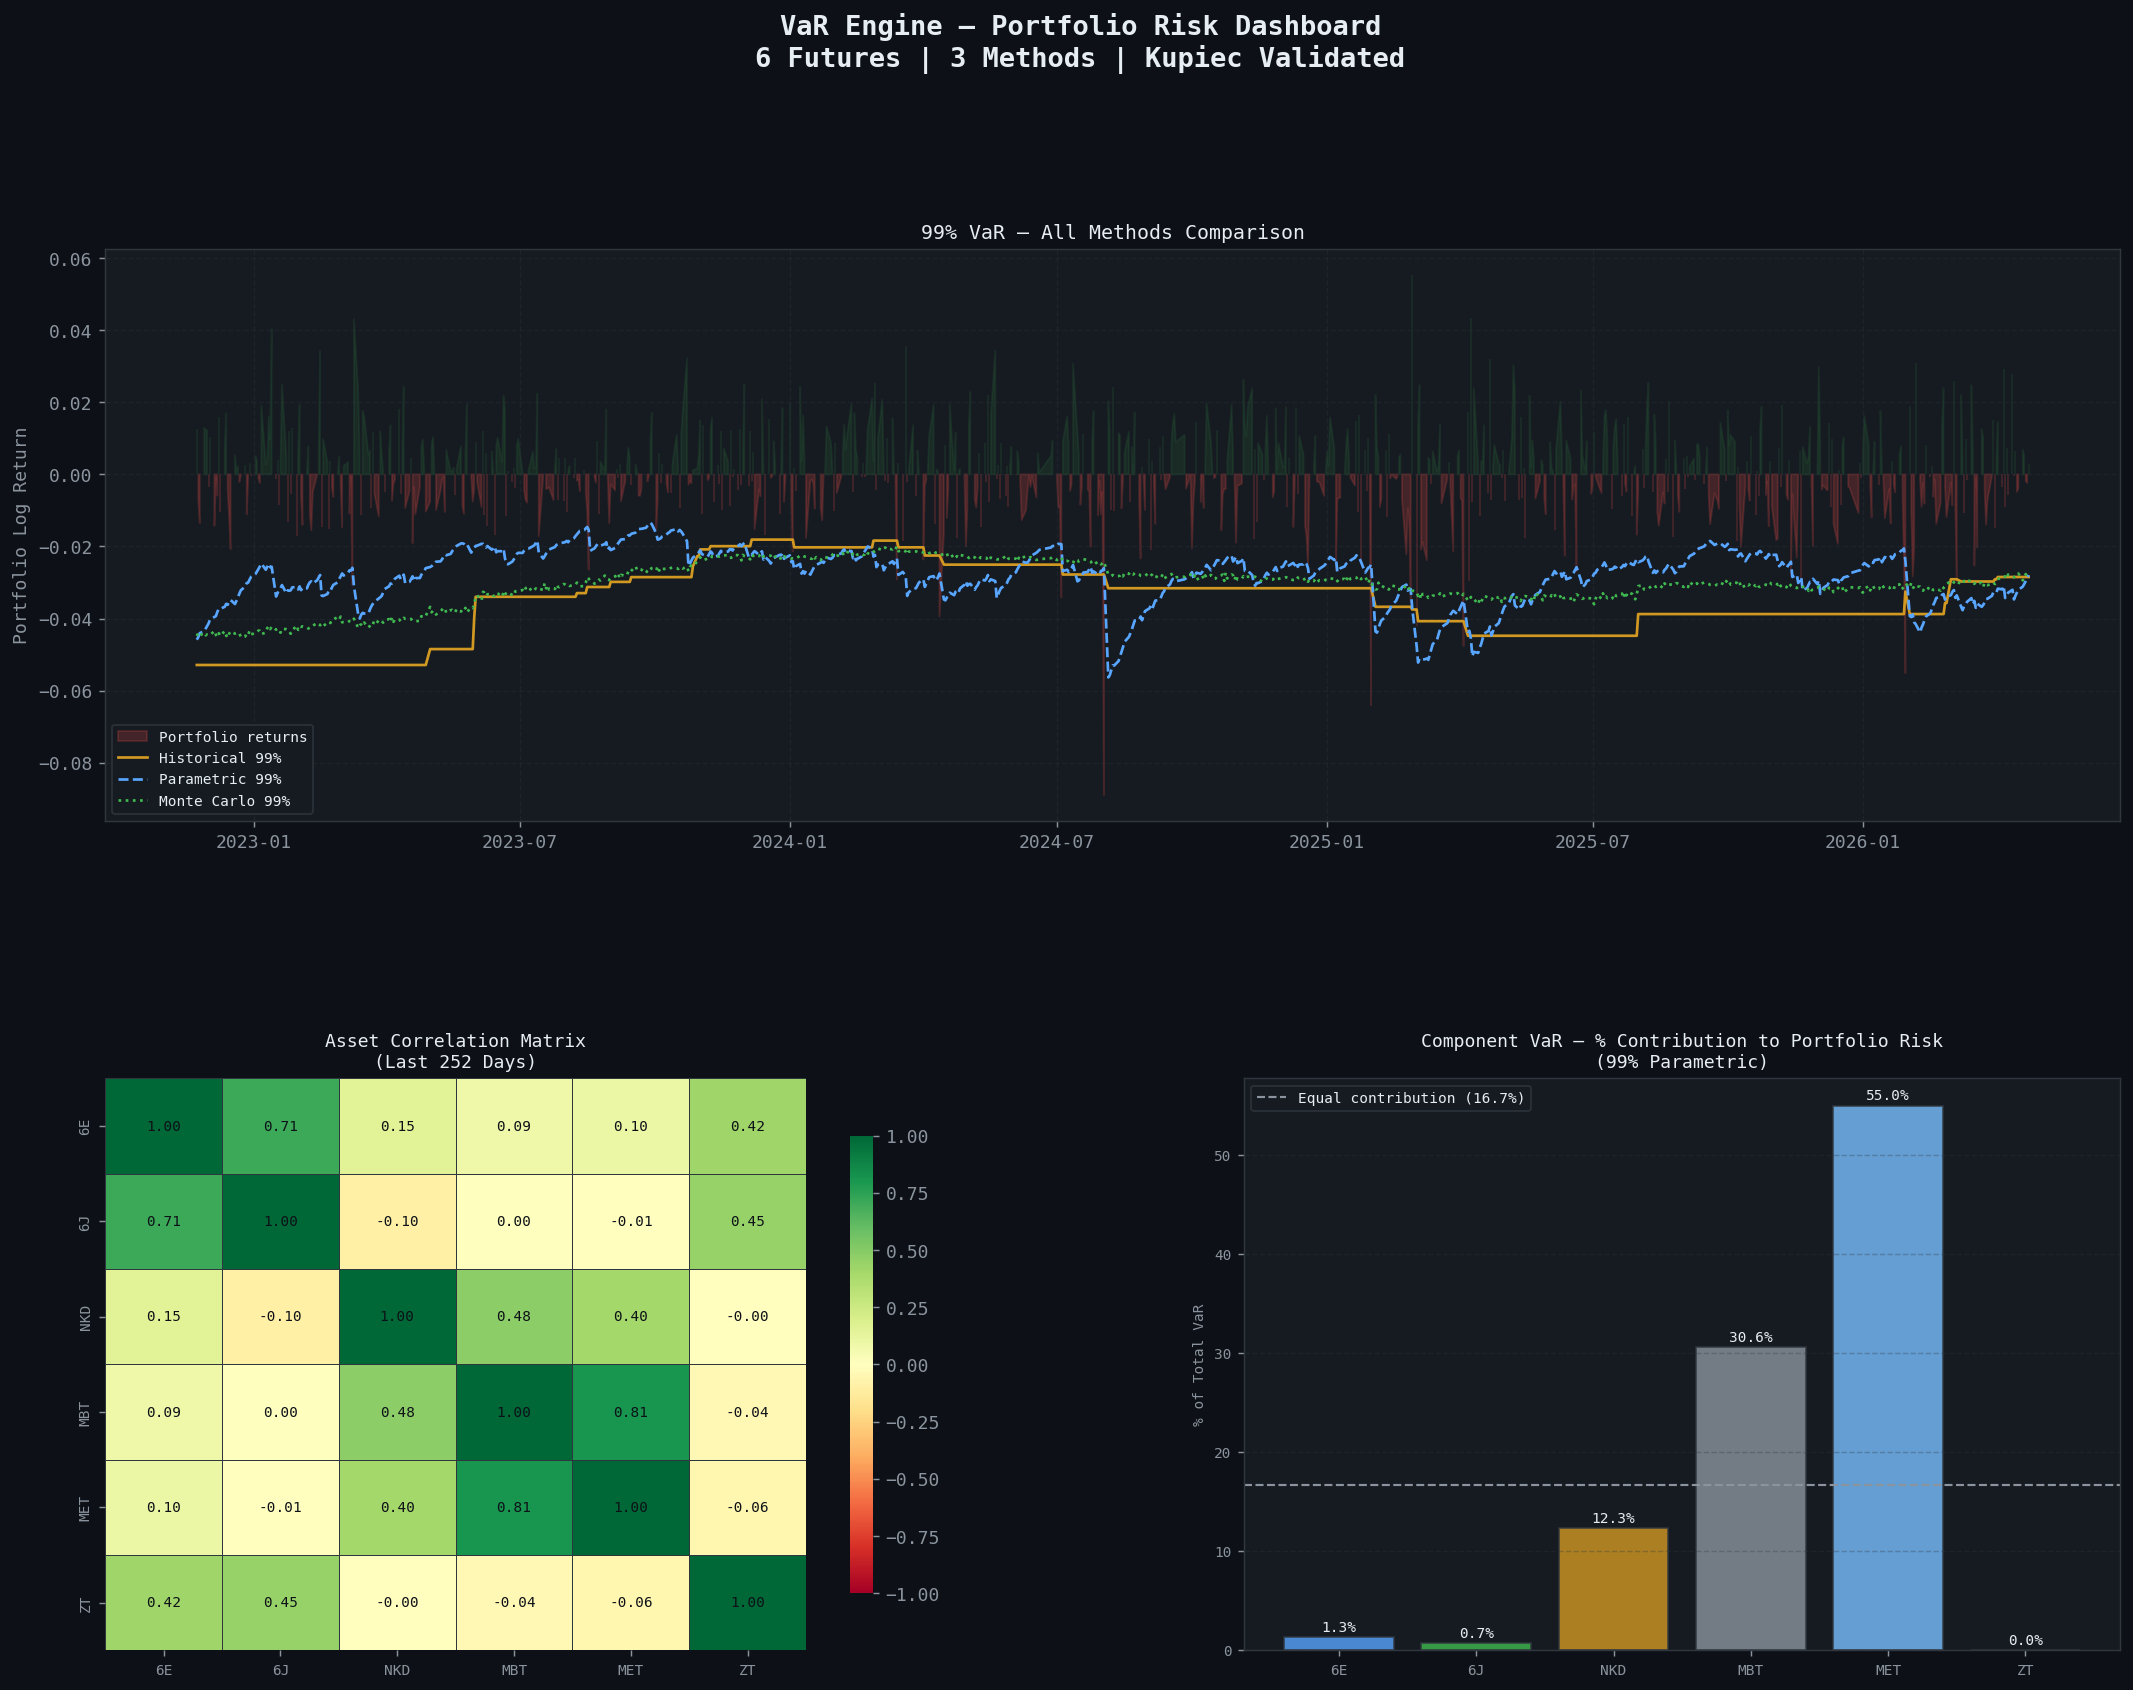


════════════════════════════════════════════════════════════
  PORTFOLIO RISK SUMMARY — Current Estimates (99% VaR)
════════════════════════════════════════════════════════════
  Historical VaR  : -0.0285  | CVaR: -0.0379
  Parametric VaR  : -0.0279  | CVaR: -0.0321
  Monte Carlo VaR : -0.0286  | CVaR: -0.0332

  Largest risk contributor : MET (55.0% of portfolio VaR)
  Smallest contributor     : ZT (0.0% of portfolio VaR)
════════════════════════════════════════════════════════════


In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# FINAL DASHBOARD — 4-Panel Summary
# ─────────────────────────────────────────────────────────────────────────────
N_ASSETS = len(ASSETS)
def component_var(ret_df: pd.DataFrame,
                  weights: np.ndarray = WEIGHTS,
                  window: int = ROLLING_WINDOW,
                  confidence: float = 0.99) -> pd.Series:
    """
    Component VaR = marginal contribution of each asset to total portfolio VaR.
    Uses the most recent window only (snapshot for dashboard).
    """
    z        = Z_SCORES[confidence]
    last_ret = ret_df.iloc[-window:].values
    cov      = np.cov(last_ret.T)
    sigma_p  = np.sqrt(weights @ cov @ weights)
    # Marginal VaR vector
    marginal = (cov @ weights) / sigma_p * z
    comp_var = weights * marginal
    # Normalize to % contribution
    comp_pct = comp_var / comp_var.sum() * 100
    return pd.Series(comp_pct, index=ret_df.columns)


comp = component_var(returns)

fig = plt.figure(figsize=(20, 14), facecolor=BG)
fig.suptitle('VaR Engine — Portfolio Risk Dashboard\n6 Futures | 3 Methods | Kupiec Validated',
             color=TEXT, fontsize=15, fontweight='bold', y=1.01)

gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.3)

# ── Panel 1: VaR Method Comparison ────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, :])   # full top row
common_idx = hist_var.index.intersection(param_var.index).intersection(mc_var.index)
p_ret      = portfolio_returns.loc[common_idx]

ax1.fill_between(p_ret.index, p_ret, 0,
                 where=(p_ret < 0), color=RED, alpha=0.2, label='Portfolio returns')
ax1.fill_between(p_ret.index, p_ret, 0,
                 where=(p_ret >= 0), color=GREEN, alpha=0.1)

ax1.plot(common_idx, hist_var.loc[common_idx, 'VaR_99'],
         color=ORANGE, lw=1.5, label='Historical 99%')
ax1.plot(common_idx, param_var.loc[common_idx, 'VaR_99'],
         color=BLUE, lw=1.5, ls='--', label='Parametric 99%')
ax1.plot(common_idx, mc_var.loc[common_idx, 'VaR_99'],
         color=GREEN, lw=1.5, ls=':', label='Monte Carlo 99%')

ax1.set_title('99% VaR — All Methods Comparison', color=TEXT, fontsize=11)
ax1.set_ylabel('Portfolio Log Return', color=MUTED)
ax1.legend(fontsize=8, loc='lower left')
ax1.grid(True, alpha=0.3)

# ── Panel 2: Correlation Heatmap ───────────────────────────────────────────────
ax2  = fig.add_subplot(gs[1, 0])
corr = returns.iloc[-ROLLING_WINDOW:].corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

sns.heatmap(corr, ax=ax2, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            linewidths=0.5, linecolor=BORDER,
            annot_kws={'size': 8, 'color': BG},
            cbar_kws={'shrink': 0.8})

ax2.set_title('Asset Correlation Matrix\n(Last 252 Days)',
              color=TEXT, fontsize=10)
ax2.tick_params(colors=MUTED, labelsize=8)

# ── Panel 3: Component VaR ─────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 1])
colors_bar = [ASSET_COLORS.get(a, BLUE) for a in comp.index]
bars = ax3.bar(comp.index, comp.values,
               color=colors_bar, alpha=0.8,
               edgecolor=BORDER, linewidth=1)

ax3.axhline(100 / N_ASSETS, color=MUTED, lw=1.2, ls='--',
            label=f'Equal contribution ({100/N_ASSETS:.1f}%)')

for bar, val in zip(bars, comp.values):
    ax3.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.3,
             f'{val:.1f}%', ha='center', va='bottom',
             fontsize=8, color=TEXT)

ax3.set_title('Component VaR — % Contribution to Portfolio Risk\n(99% Parametric)',
              color=TEXT, fontsize=10)
ax3.set_ylabel('% of Total VaR', color=MUTED, fontsize=8)
ax3.legend(fontsize=8)
ax3.tick_params(labelsize=8)
ax3.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('07_dashboard.png', dpi=130,
            bbox_inches='tight', facecolor=BG)
plt.show()

# ── Final Summary ──────────────────────────────────────────────────────────────
print("\n" + "═" * 60)
print("  PORTFOLIO RISK SUMMARY — Current Estimates (99% VaR)")
print("═" * 60)
print(f"  Historical VaR  : {hist_var['VaR_99'].iloc[-1]:.4f}  "
      f"| CVaR: {hist_var['CVaR_99'].iloc[-1]:.4f}")
print(f"  Parametric VaR  : {param_var['VaR_99'].iloc[-1]:.4f}  "
      f"| CVaR: {param_var['CVaR_99'].iloc[-1]:.4f}")
print(f"  Monte Carlo VaR : {mc_var['VaR_99'].iloc[-1]:.4f}  "
      f"| CVaR: {mc_var['CVaR_99'].iloc[-1]:.4f}")
print(f"\n  Largest risk contributor : "
      f"{comp.idxmax()} ({comp.max():.1f}% of portfolio VaR)")
print(f"  Smallest contributor     : "
      f"{comp.idxmin()} ({comp.min():.1f}% of portfolio VaR)")
print("═" * 60)

## Interpretation
Parametric VaR fails at the 99% confidence level (p=0.027).
This is expected and instructive — not a model error.

The normality assumption breaks down in the deep tail.
When returns exhibit excess kurtosis (as shown in Section 1),
parametric models systematically underestimate extreme losses.

This is precisely why Historical and Monte Carlo VaR exist:
they make no distributional assumption and pass at both levels.

Takeaway: For a multi-asset futures portfolio with fat-tailed
returns, Historical or Monte Carlo VaR is preferred at 99%+.
Parametric VaR remains useful for speed and decomposition
at moderate confidence levels (95%).

---

## Notebook Series — Quantitative Research Portfolio

This notebook is part of a structured series on quantitative finance methodology.  
Each notebook builds on the previous — from data sampling to risk quantification.

| # | Notebook | Topic |
|---|----------|-------|
| 1 | [Dollar Bars vs Time Bars — Statistical Foundation](https://github.com/Tejemouti/Dollar-Bars-Sampling) | Why time-based bars fail statistically and how dollar bars fix it |
| 2 | [Purged Cross-Validation vs K-Fold](https://github.com/Tejemouti/Purged-Cross-Validation-vs-KFold) | Eliminating look-ahead bias in financial ML validation |
| 3 | [Time Bars vs Dollar Bars — Practitioner's Assessment](https://github.com/Tejemouti/Time-Bars-vs-Dollar-Bars-Practitioners-Assessment) | When statistical optimality meets engineering reality |
| 4 | [Quadratic Regression — ROA Analysis](https://github.com/Tejemouti/Quadratic-Regression-application) | Identifying ROA drivers via inverted U-shape methodology |
| **5** | **This Notebook — Multi-Asset VaR Engine** | Historical + Parametric + Monte Carlo VaR on real futures data |
| 6 | Coming soon — Supply & Demand on Dollar Bars | Translating discretionary S&D logic into testable statistical signals |

---

*All notebooks use real market data — no synthetic datasets.*  
*Repository: [github.com/Tejemouti](https://github.com/Tejemouti)*  
*Author: Abir Tejemouti | Quantitative Researcher | Rabat, Morocco*